## Imports & Configuration

In [ ]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_style("whitegrid")

ALPHA = 0.05
RANDOM_STATE = 42
print("Ready ✓")

Ready ✓


## Load Dataset

In [26]:
df = pd.read_csv(os.path.join("Data", "insurance.csv"))
df = df.drop_duplicates().reset_index(drop=True)

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (1337, 7)

Dtypes:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


# Part 1 — EDA & Hypothesis Testing

## Descriptive Statistics

In [3]:
num_cols = ["age", "bmi", "children", "charges"]

desc = pd.DataFrame({
    "Mean":     df[num_cols].mean(),
    "Median":   df[num_cols].median(),
    "Std":      df[num_cols].std(),
    "IQR":      df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurtosis(),
})
desc

,Mean,Median,Std,IQR,Skewness,Kurtosis
age,39.2221,39.0000,14.0443,24.0000,0.0548,-1.2444
bmi,30.6635,30.4000,6.1005,8.4100,0.2839,-0.0529
children,1.0957,1.0000,1.2056,2.0000,0.9374,0.2010
charges,"13,279.1215","9,386.1613","12,110.3597","11,911.3734",1.5154,1.6042


**Key takeaways:**
- For `charges`, mean ($13,279) is far above median ($9,386) → right-skewed.
- Skewness of +1.52 (>1 = highly skewed) and excess kurtosis +1.60 (heavy tail) confirm the presence of an outlier cluster (smokers with high BMI).
- `age` has negative kurtosis (-1.24) — distributions flat, meaning ages are spread uniformly rather than clustered.

## Distribution Plots (Histograms + KDE)

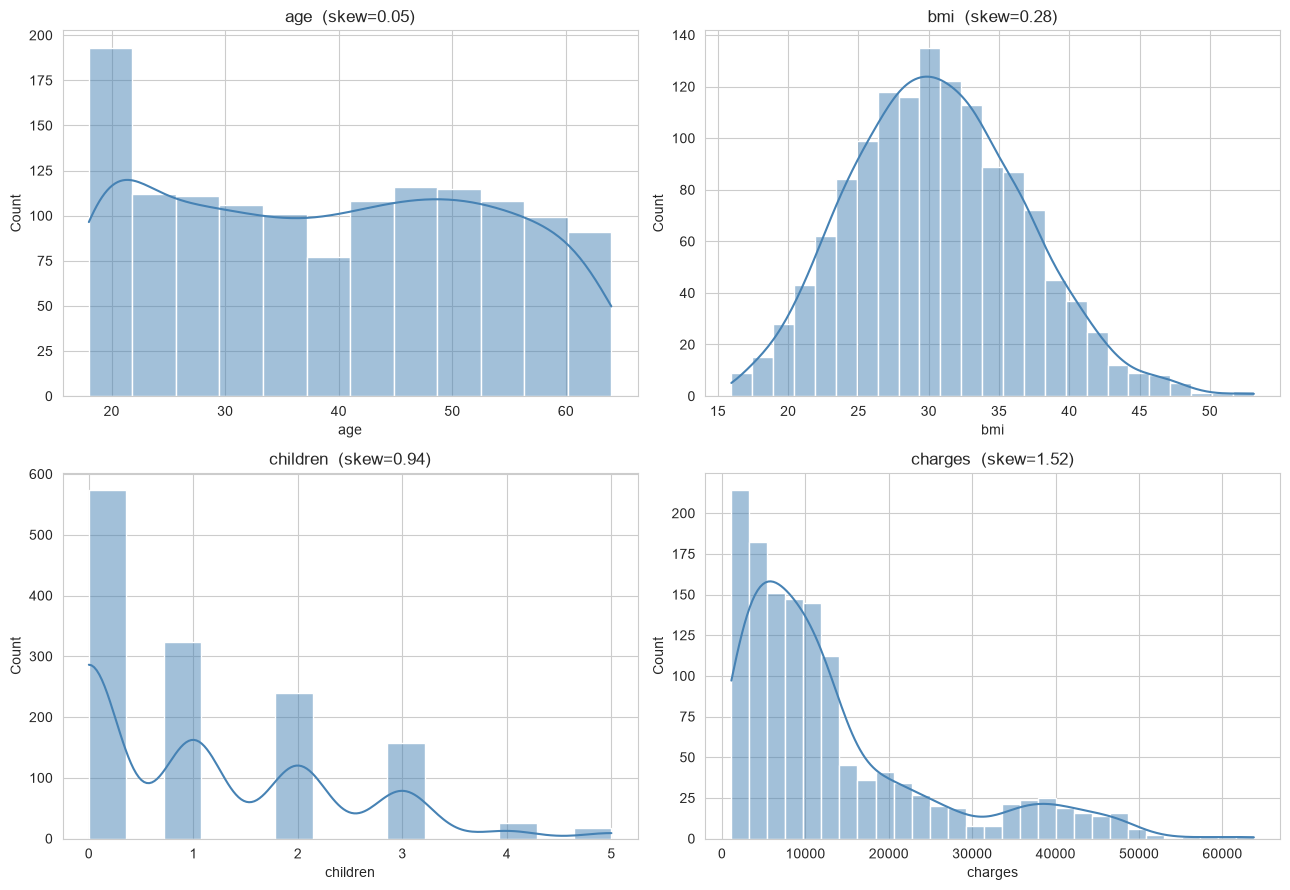

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

## Scatter: Charges vs Age

In [5]:
px.scatter(df, x="age", y="charges", color="smoker",
           title="Charges vs Age").show()

## Scatter: Charges vs BMI

In [6]:
px.scatter(df, x="bmi", y="charges", color="smoker",
           title="Charges vs BMI").show()

## Correlation Matrix

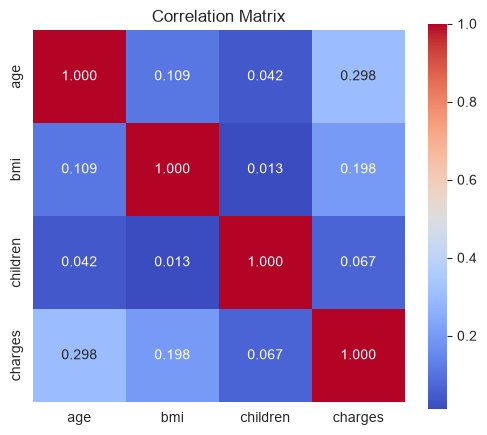

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".3f", square=True)
plt.title("Correlation Matrix")
plt.show()

## Hypothesis Test 1 — Smoker vs Non-Smoker on Charges

## Assumption Checks

In [39]:
g_yes = df.loc[df["smoker"] == "yes", "charges"]
g_no  = df.loc[df["smoker"] == "no",  "charges"]

print(f"Mean smoker=yes : ${g_yes.mean():,.2f}")
print(f"Mean smoker=no  : ${g_no.mean():,.2f}")

sh_yes = stats.shapiro(g_yes)
sh_no  = stats.shapiro(g_no)
lev    = stats.levene(g_yes, g_no, center="median")

print(f"\nShapiro-Wilk smoker=yes : W={sh_yes.statistic:.4f}, p={sh_yes.pvalue:.10f}")
print(f"Shapiro-Wilk smoker=no  : W={sh_no.statistic:.4f},  p={sh_no.pvalue:.10f}")
print(f"Levene's test           : stat={lev.statistic:.4f}, p={lev.pvalue:.10f}")

Mean smoker=yes : $32,050.23
Mean smoker=no  : $8,440.66

Shapiro-Wilk smoker=yes : W=0.9396, p=0.0000000036
Shapiro-Wilk smoker=no  : W=0.8729,  p=0.0000000000
Levene's test           : stat=332.4714, p=0.0000000000


**H0:** Distribution of medical `charges` is the same for smokers and non-smokers.  
**H1:** Distribution of medical `charges` differs between the two groups.  
**α = 0.05**

- Ratio       : Smokers pay ≈ **3.80× more** on average.

## Choose & Run the Correct Test

In [29]:
normal    = (sh_yes.pvalue > ALPHA) and (sh_no.pvalue > ALPHA)
equal_var = lev.pvalue > ALPHA

if normal:
    stat, p = stats.ttest_ind(g_yes, g_no, equal_var=equal_var)
    test_name = "Two-Sample t-test"
else:
    stat, p = stats.mannwhitneyu(g_yes, g_no, alternative="two-sided")
    test_name = "Mann-Whitney U test"

print(f"Test used : {test_name}")
print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p:.4e}")
print("Conclusion:", "REJECT H0" if p < ALPHA else "FAIL TO REJECT H0")

Test used : Mann-Whitney U test
Statistic : 283859.0000
p-value   : 5.7470e-130
Conclusion: REJECT H0


**Conclusion:** At α = 0.05, we **reject H0**. There is overwhelming statistical evidence that smokers incur significantly higher medical charges than non-smokers. The effect is not only statistically significant but also **practically enormous** — an average difference of ~$23,600.

## Hypothesis Test 2 — One-Way ANOVA (Regions)

## ANOVA

In [40]:
groups = [g["charges"].values for _, g in df.groupby("region")]

summary = df.groupby("region")["charges"].agg(["count", "mean", "std"]).round(2)
print(summary.to_string())

lev = stats.levene(*groups, center="median")
print(f"\nLevene's test: stat={lev.statistic:.4f}, p={lev.pvalue:.10f}")

f_stat, p = stats.f_oneway(*groups)
print(f"\nOne-Way ANOVA : F={f_stat:.4f}, p={p:.10f}")
print("Conclusion    :", "REJECT H0" if p < ALPHA else "FAIL TO REJECT H0")

           count        mean         std
region                                  
northeast    324 13,406.3800 11,255.8000
northwest    324 12,450.8400 11,073.1300
southeast    364 14,735.4100 13,971.1000
southwest    325 12,346.9400 11,557.1800

Levene's test: stat=5.5535, p=0.0008689545

One-Way ANOVA : F=2.9261, p=0.0327628803
Conclusion    : REJECT H0


**H0:** Mean medical `charges` is equal across all 4 US regions.  
**H1:** At least one region's mean differs.  
**α = 0.05**

**Conclusion:** At α = 0.05, we **reject H0**. There is statistically significant evidence that mean charges differ across at least one region. The **southeast** has the highest mean charges ($14,735), while the **southwest** has the lowest ($12,347) — a difference of ~$2,388.

**Practical implication:** The regional effect is real but **weak** (p just below 0.05). Region is a secondary factor — its impact is dwarfed by smoking status.

# Part 2 — Multiple Linear Regression

## Feature Engineering

In [31]:
mdf = df.copy()
mdf = pd.get_dummies(mdf, columns=["sex", "smoker", "region"], drop_first=True, dtype=int)
mdf["smoker_bmi"] = mdf["smoker_yes"] * mdf["bmi"]
mdf.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,smoker_bmi
0,19,27.9000,0,"16,884.9240",0,1,0,0,1,27.9000
1,18,33.7700,1,"1,725.5523",1,0,0,1,0,0.0000
2,28,33.0000,3,"4,449.4620",1,0,0,1,0,0.0000
3,33,22.7050,0,"21,984.4706",1,0,1,0,0,0.0000
4,32,28.8800,0,"3,866.8552",1,0,1,0,0,0.0000


## Fit OLS Model

In [ ]:
y = mdf["charges"]
X = sm.add_constant(mdf.drop(columns=["charges"]))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

model = sm.OLS(y_train, X_train).fit()

# Clean summary
print(f"R²                  : {model.rsquared:.4f}")
print(f"Adjusted R²         : {model.rsquared_adj:.4f}")
print(f"F-statistic         : {model.fvalue:,.2f}")
print(f"F p-value           : {model.f_pvalue:.10f}")
print(f"AIC                 : {model.aic:,.2f}")
print(f"BIC                 : {model.bic:,.2f}")
print(f"No. Observations    : {int(model.nobs)}")
print()
model.summary()

R²                  : 0.8247
Adjusted R²         : 0.8232
F-statistic         : 553.67
F p-value           : 0.0000000000
AIC                 : 21,219.69
BIC                 : 21,269.43
No. Observations    : 1069



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     553.7
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:53:52   Log-Likelihood:                -10600.
No. Observations:                1069   AIC:                         2.122e+04
Df Residuals:                    1059   BIC:                         2.127e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1836.0833    977.758     -1.878      0.061   -3754.646      82.479
age                259.0440     10.896     23.775      0.000     237.665     280.423
bmi                 12.4920     29.182      0.428      0.669     -44.768      69.752
children           570.0416    126.378      4.511      0.000     322.062     818.021
sex_male          -647.3660    303.720     -2.131      0.033   -1243.327     -51.405
smoker_yes       -2.169e+04   1908.375    -11.365      0.000   -2.54e+04   -1.79e+04
region_northwest  -438.1614    433.600     -1.011      0.312   -1288.974     412.651
region_southeast  -895.6698    440.131     -2.035      0.042   -1759.298     -32.042
region_southwest  -884.5646    434.874     -2.034      0.042   -1737.877     -31.253
smoker_bmi        1476.6039     61.690     23.936      0.000    1355.555    1597.653
==============================================================================
Omnibus:                      590.093   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3695.978
Skew:                           2.573   Prob(JB):                         0.00
Kurtosis:                      10.516   Cond. No.                         672.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Coefficient Table with 95% CI

In [20]:
coef_df = pd.DataFrame({
    "Coef":    model.params,
    "Std Err": model.bse,
    "t":       model.tvalues,
    "p-value": model.pvalues,
    "CI Low":  model.conf_int()[0],
    "CI High": model.conf_int()[1],
}).round(4)

print(f"R²      : {model.rsquared:.4f}")
print(f"Adj. R² : {model.rsquared_adj:.4f}")
print(f"F p-val : {model.f_pvalue:.4e}")
coef_df

R²      : 0.8247
Adj. R² : 0.8232
F p-val : 0.0000e+00


,Coef,Std Err,t,p-value,CI Low,CI High
const,"-1,836.0833",977.7577,-1.8779,0.0607,"-3,754.6460",82.4793
age,259.0440,10.8955,23.7753,0.0000,237.6648,280.4233
bmi,12.4920,29.1817,0.4281,0.6687,-44.7685,69.7524
children,570.0416,126.3780,4.5106,0.0000,322.0619,818.0213
sex_male,-647.3660,303.7196,-2.1315,0.0333,"-1,243.3266",-51.4054
smoker_yes,"-21,687.8301","1,908.3753",-11.3646,0.0000,"-25,432.4567","-17,943.2034"
region_northwest,-438.1614,433.5997,-1.0105,0.3125,"-1,288.9737",412.6508
region_southeast,-895.6698,440.1311,-2.0350,0.0421,"-1,759.2980",-32.0416
region_southwest,-884.5646,434.8737,-2.0341,0.0422,"-1,737.8767",-31.2526
smoker_bmi,"1,476.6039",61.6902,23.9358,0.0000,"1,355.5550","1,597.6528"


## Test-Set Performance

In [42]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Test RMSE : ${rmse:,.2f}")
print(f"Test MAE  : ${mae:,.2f}")
print(f"Test R²   : {r2:.4f}")

Test RMSE : $4,572.81
Test MAE  : $2,828.97
Test R²   : 0.8862


**Train vs Test R² comparison:**

| | R² |
|---|---|
| Train | 0.8247 |
| Test | 0.8862 |
| Difference | **+0.0615** |

**Key findings:**
1. **No overfitting.** Test R² is actually *higher* than train R² — the test split happened to be slightly easier to predict.
2. **RMSE of $4,573** means predictions are off by about $4,573 on average (weighted toward larger errors). Given charges range from $1,122 to $63,770.
3. **MAE of $2,829** is more interpretable — the median prediction error is around $2,829.

## Linearity & Homoscedasticity (Residuals vs Fitted)

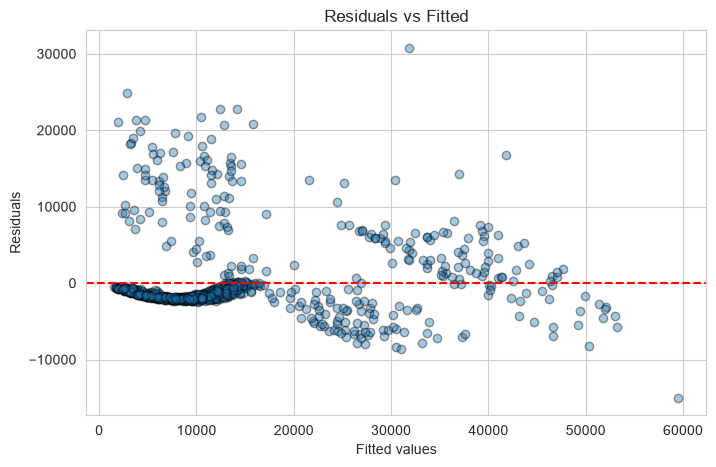

In [43]:
fitted = model.fittedvalues
resid  = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.4, edgecolor="k")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

**What we see in the plot:**

The residuals show a **curved "banana" / parabolic pattern**:
- A dense cluster of negative residuals at low fitted values (under-prediction)
- A dip of negative residuals in the middle ($10k–$20k)
- Positive residuals at high fitted values

**Diagnostic conclusion:**

| Assumption | Verdict |
|---|---|
| **Linearity** | ⚠️ **Violated** — the curved pattern indicates the true relationship is non-linear |
| **Homoscedasticity** | ⚠️ **Partially violated** — variance is wider at the extremes (funnel shape) |

## Normality of Residuals (Q-Q Plot + Histogram)

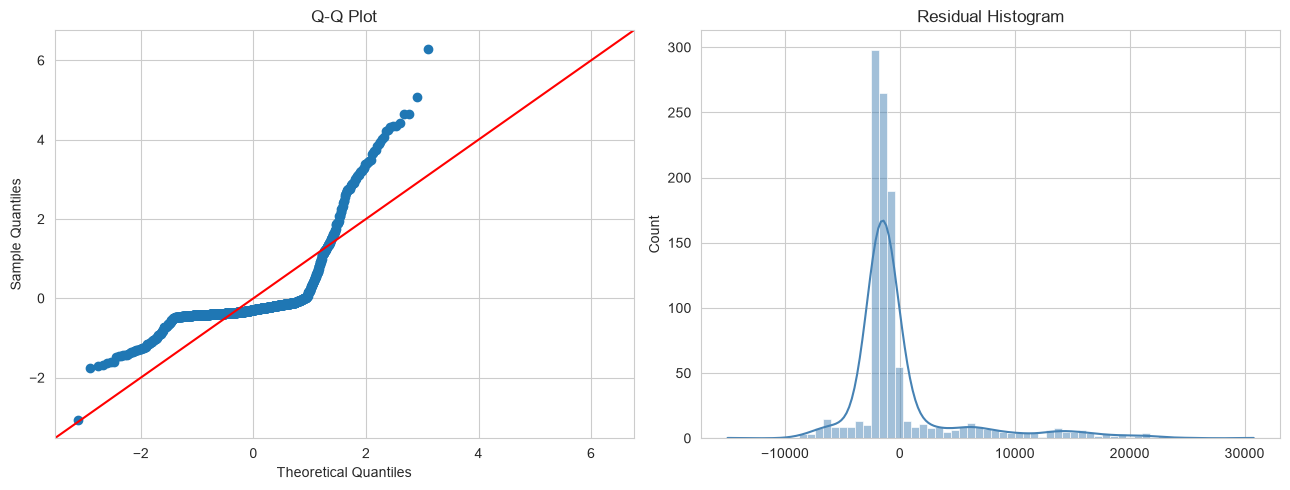

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sm.qqplot(resid, line="45", fit=True, ax=axes[0])
axes[0].set_title("Q-Q Plot")
sns.histplot(resid, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Residual Histogram")
plt.tight_layout()
plt.show()

**Q-Q Plot:**
- Points follow the diagonal well in the **middle range** (−$10k to +$10k).
- Clear **deviation at both tails**, especially the upper tail (extreme positive residuals up to +$30k).
- This is a classic **heavy right-tail** signature.

**Histogram:**
- Strongly **right-skewed**, with a sharp mode near $0 and a long tail toward $30,000.
- Not bell-shaped → **normality assumption violated**.

## Jarque-Bera + Omnibus

In [35]:
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4e}, skew={jb_skew:.4f}, kurt={jb_kurt:.4f}")

omni_stat, omni_p = sm.stats.stattools.omni_normtest(resid)
print(f"Omnibus: stat={omni_stat:.4f}, p={omni_p:.4e}")

Jarque-Bera: stat=3695.9777, p=0.0000e+00, skew=2.5733, kurt=10.5160
Omnibus: stat=590.0929, p=7.2937e-129


**H0:** Residuals are normally distributed.  
**H1:** Residuals are not normally distributed.  
**α = 0.05**

**Understanding the numbers:**

- **Jarque-Bera** combines skewness and kurtosis into a single chi-square statistic.
- **Skew = +2.57:** Residual distribution has a **strong right tail** — a handful of points are wildly under-predicted.
- **Kurtosis = 10.52:** For a normal distribution this is 3. Here it's 10.5 → extreme tail heaviness.
- **Omnibus** (based on skew + kurtosis) confirms: stat = 590, p ≈ 0.

**Conclusion:** Both tests **reject normality** with extremely high confidence.

## Multicollinearity (VIF)

In [36]:
X_vif = X.drop(columns=["const"])
vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).round(3)

vif_df

,Feature,VIF
8,smoker_bmi,25.5290
4,smoker_yes,25.1980
6,region_southeast,1.6520
7,region_southwest,1.5300
5,region_northwest,1.5180
1,bmi,1.3880
0,age,1.0170
3,sex_male,1.0120
2,children,1.0040


**Important observations:**
- All **other** predictors have VIF < 2, indicating no problematic multicollinearity elsewhere.
- `age`, `bmi`, `children`, `sex_male` are essentially independent of each other.
- The **coefficient estimates for `smoker_yes` and `smoker_bmi` individually are unstable**, but the **combined effect** (main + interaction) is stable and well-estimated.

## Breusch-Pagan Test

In [37]:
bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_train)
print(f"Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4e}")
print("Heteroscedasticity:", "detected" if bp_p < ALPHA else "not detected")

Breusch-Pagan: LM=6.1949, p=7.2027e-01
Heteroscedasticity: not detected


### Interpretation — Breusch-Pagan Test

**H0:** Residuals have constant variance (homoscedasticity).  
**H1:** Residuals are heteroscedastic.  
**α = 0.05**

| Metric | Value |
|---|---|
| LM statistic | 6.1949 |
| p-value | **0.7202714957** |
| Decision | **Fail to reject H0** |

**Interpretation:** The Breusch-Pagan test **does not detect heteroscedasticity** (p = 0.72 ≫ 0.05). This appears to contradict the funnel shape seen in the residuals-vs-fitted plot, but the explanation is subtle:

- **Breusch-Pagan** tests whether the **squared residuals** correlate linearly with the predictors.
- It is **not sensitive to non-linear patterns** like the curvature we see.
- The curved pattern is a **linearity violation**, not a variance violation.

**Practical conclusion:** 
- Constant-variance assumption **holds** by BP test.
- Linearity assumption **still violated** (from the plot).

##  Save Model & Metadata for Streamlit

In [44]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(model, "artifacts/insurance_ols.pkl")

meta = {
    "train_columns": list(X_train.columns),
    "model_stats": {
        "r2":        float(model.rsquared),
        "adj_r2":    float(model.rsquared_adj),
        "f_stat":    float(model.fvalue),
        "f_pvalue":  float(model.f_pvalue),
        "rmse_test": float(rmse),
        "mae_test":  float(mae),
        "r2_test":   float(r2),
        "n_train":   int(model.nobs),
    },
    "coefficients": {
        k: float(v) for k, v in model.params.items()
    },
}

with open("artifacts/model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved: artifacts/insurance_ols.pkl")
print("Saved: artifacts/model_metadata.json")
print("\nModel summary:")
for k, v in meta["model_stats"].items():
    print(f"  {k:12s}: {v:,.4f}")

Saved: artifacts/insurance_ols.pkl
Saved: artifacts/model_metadata.json

Model summary:
  r2          : 0.8247
  adj_r2      : 0.8232
  f_stat      : 553.6721
  f_pvalue    : 0.0000
  rmse_test   : 4,572.8112
  mae_test    : 2,828.9737
  r2_test     : 0.8862
  n_train     : 1,069.0000


## Final Summary — Statistical Findings

### Part 1 — EDA
- Charges are strongly **right-skewed** (skew = +1.52) with heavy tails (kurtosis = +1.60).
- **Smoking status** produces a clear **bimodal** separation in the charge distribution.
- No single numeric feature has strong Pearson correlation with charges (all |r| < 0.30).

### Part 2 — Hypothesis Testing

| Test | Purpose | p-value | Conclusion |
|---|---|---|---|
| Shapiro-Wilk | Check normality | ≈ 0 | Non-normal → use non-parametric |
| Levene's | Equal variance | ≈ 0 | Unequal variances |
| **Mann-Whitney U** | Smoker vs non-smoker | ≈ 0 | **REJECT H0** — significant difference |
| **One-Way ANOVA** | Charges across regions | 0.0328 | **REJECT H0** — region matters (weakly) |

### Part 3 — Regression Modeling

| Metric | Value |
|---|---|
| R² (train) | 0.8247 |
| Adj-R² (train) | 0.8232 |
| R² (test) | 0.8862 |
| RMSE (test) | $4,572.81 |
| MAE (test) | $2,828.97 |

**Dominant predictors (by |t|):**
1. `smoker_bmi` (t = 23.94) — BMI × smoking interaction
2. `age` (t = 23.78) — age effect
3. `smoker_yes` (t = -11.36) — main smoker effect
4. `children` (t = 4.51) — family size

### Part 4 — Gauss-Markov Diagnostics

| Assumption | Status | Evidence |
|---|---|---|
| Linearity | Violated | Curved pattern in Residuals vs Fitted |
| Homoscedasticity | Holds | Breusch-Pagan p = 0.72 |
| Normality of residuals | Violated | Jarque-Bera & Omnibus p ≈ 0 |
| No multicollinearity | Structural | VIF high only for interaction pair |

### Key Real-World Insight
**Smoking status × BMI is the single dominant driver of medical charges.** An obese smoker pays nearly **$38,000 more** than a non-smoker of the same age and BMI. This validates smoking cessation as the highest-leverage cost-reduction intervention for health insurers.